In [ ]:
!pip install easyocr
!pip install imutils

     |████████████████████████████████| 63.6 MB 26 kB/s 
     |████████████████████████████████| 37.1 MB 53 kB/s 


In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils
import easyocr

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)

Mounted at /content/gdrive


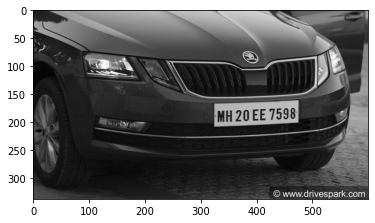

In [ ]:
img_path = '/content/gdrive/MyDrive/NPD data_set/Image_1.jpg'
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

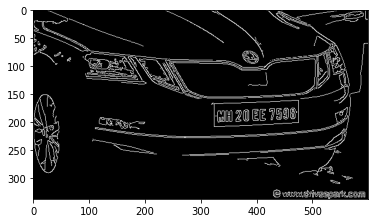

In [ ]:
bilfilter = cv2.bilateralFilter(gray, 11, 17, 17)
edged = cv2.Canny(bilfilter, 30, 200)
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

In [ ]:
keypts = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypts)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10];

In [ ]:
location = None;
for x in contours:
  approx = cv2.approxPolyDP(x, 10, True)
  if len(approx) == 4:
    location = approx
    break

In [ ]:
location

array([[[475, 161]],

       [[321, 166]],

       [[324, 208]],

       [[475, 201]]], dtype=int32)

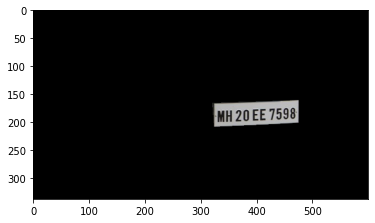

In [ ]:
mask = np.zeros(gray.shape, np.uint8)
new_img = cv2.drawContours(mask, [location], 0, 255, -1)
new_img = cv2.bitwise_and(img, img, mask=mask)
plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))

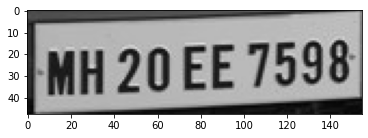

In [ ]:
(x, y) = np.where(mask == 255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
crop_img = gray[x1:x2+1, y1:y2+1]
plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))

In [ ]:
reader = easyocr.Reader(['en'])
res = reader.readtext(crop_img)
res

[([[5, 9], [155, 9], [155, 47], [5, 47]], 'MH 20EE 7598', 0.8389716325362976)]

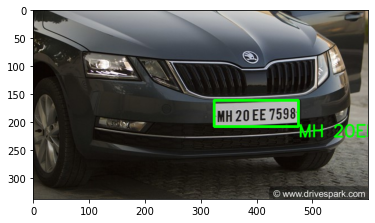

In [ ]:
text = res[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace = font, fontScale = 1, color=(0, 255, 0), thickness=2, lineType = cv2.LINE_AA)
res = cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0),3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))